# Sequence-Based HMM for Activity Recognition

This notebook implements a **proper Hidden Markov Model (HMM)** using temporal sequences of feature observations.

## Approach

**Key Difference from Previous Implementation:**
- **Previous (incorrect)**: Each recording → 1 feature vector → independent classification
- **Current (correct)**: Each recording → sequence of N feature vectors → sequence modeling

## Model Architecture

We train **one HMM per activity class** (4 HMMs total):
- Each HMM learns the temporal patterns of one activity
- Classification: compute log-likelihood for each HMM, choose highest

## HMM Components

- **Hidden States (Z)**: Internal states within each activity (e.g., phases of walking)
- **Observations (X)**: Feature vectors from time windows (time-domain + frequency-domain)
- **Transition Matrix (A)**: Probabilities of moving between hidden states
- **Emission Probabilities (B)**: Gaussian distributions for feature observations per state
- **Initial State Probabilities (π)**: Starting distribution

## Algorithms

- **Training**: **Baum-Welch** (Expectation-Maximization) algorithm
- **Decoding**: **Viterbi** algorithm for most likely state sequence
- **Classification**: Log-likelihood scoring across activity-specific HMMs

## 1. Import Required Libraries

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import pickle

# HMM library
try:
    from hmmlearn import hmm
    print("✓ hmmlearn loaded successfully")
except ImportError:
    print("ERROR: hmmlearn not installed")
    print("Install with: pip install hmmlearn")

✓ hmmlearn loaded successfully


## 2. Configuration

In [2]:
# Paths
FEATURES_DIR = "sequence_features"
OUTPUT_DIR = "hmm_sequence_results"

# HMM Parameters
N_HIDDEN_STATES = 3      # Number of hidden states per activity HMM
N_ITER = 100             # Training iterations
COVARIANCE_TYPE = "diag" # Diagonal covariance (faster, works well)
RANDOM_SEED = 42

# Activities
ACTIVITIES = ["jumping", "standing", "still", "walking"]

print(f"Configuration:")
print(f"  Features directory: {FEATURES_DIR}/")
print(f"  Output directory: {OUTPUT_DIR}/")
print(f"  Hidden states per HMM: {N_HIDDEN_STATES}")
print(f"  Training iterations: {N_ITER}")
print(f"  Covariance type: {COVARIANCE_TYPE}")
print(f"  Activities: {', '.join(ACTIVITIES)}")

Configuration:
  Features directory: sequence_features/
  Output directory: hmm_sequence_results/
  Hidden states per HMM: 3
  Training iterations: 100
  Covariance type: diag
  Activities: jumping, standing, still, walking


## 3. Load Sequence Data

In [3]:
def load_sequence_features(features_dir, split):
    """
    Load all sequences for a given split (train/test).
    
    Returns:
        sequences: list of dicts with keys: 
            - activity: activity name
            - sequence_id: unique identifier
            - features: np.array of shape (n_windows, n_features)
            - lengths: n_windows
    """
    sequences = []
    
    split_dir = os.path.join(features_dir, split)
    
    # Iterate through all sequence directories
    for seq_id in sorted(os.listdir(split_dir)):
        seq_path = os.path.join(split_dir, seq_id)
        
        if not os.path.isdir(seq_path):
            continue
        
        # Load features
        features_npy = os.path.join(seq_path, "features.npy")
        metadata_json = os.path.join(seq_path, "features_metadata.json")
        
        if not os.path.exists(features_npy) or not os.path.exists(metadata_json):
            continue
        
        features = np.load(features_npy)
        
        with open(metadata_json) as f:
            metadata = json.load(f)
        
        sequences.append({
            "sequence_id": seq_id,
            "activity": metadata["activity"],
            "features": features,
            "n_windows": features.shape[0],
            "n_features": features.shape[1]
        })
    
    return sequences


# Load train and test sequences
train_sequences = load_sequence_features(FEATURES_DIR, "train")
test_sequences = load_sequence_features(FEATURES_DIR, "test")

print(f"\n✓ Loaded sequences")
print(f"  Training sequences: {len(train_sequences)}")
print(f"  Test sequences: {len(test_sequences)}")

# Check feature dimensions
if train_sequences:
    n_features = train_sequences[0]["n_features"]
    print(f"  Feature dimensions: {n_features}")

# Print distribution
print(f"\n{'Split':<10} {'Activity':<15} {'Sequences':>10} {'Total Windows':>15}")
print("─"*52)
for split_name, sequences in [("Train", train_sequences), ("Test", test_sequences)]:
    for activity in ACTIVITIES:
        seqs = [s for s in sequences if s["activity"] == activity]
        n_seqs = len(seqs)
        n_windows = sum(s["n_windows"] for s in seqs)
        print(f"{split_name:<10} {activity:<15} {n_seqs:>10} {n_windows:>15}")


✓ Loaded sequences
  Training sequences: 34
  Test sequences: 16
  Feature dimensions: 90

Split      Activity         Sequences   Total Windows
────────────────────────────────────────────────────
Train      jumping                  8              57
Train      standing                 8              43
Train      still                    8              44
Train      walking                 10              56
Test       jumping                  4              20
Test       standing                 4              28
Test       still                    4              20
Test       walking                  4              20


## 4. Normalize Features

Z-score normalization using training set statistics.

In [4]:
def compute_normalization_params(sequences):
    """Compute mean and std from all training sequences."""
    all_features = []
    for seq in sequences:
        all_features.append(seq["features"])
    
    all_features = np.vstack(all_features)  # Concatenate all windows
    
    # Check for invalid values
    if np.any(np.isnan(all_features)):
        print("⚠ WARNING: NaN values detected in features! Replacing with 0...")
        all_features = np.nan_to_num(all_features, nan=0.0)
    
    if np.any(np.isinf(all_features)):
        print("⚠ WARNING: Inf values detected in features! Replacing with large finite values...")
        all_features = np.nan_to_num(all_features, posinf=1e10, neginf=-1e10)
    
    mean = np.mean(all_features, axis=0)
    std = np.std(all_features, axis=0)
    std[std == 0] = 1.0  # Avoid division by zero
    std[std < 1e-10] = 1.0  # Avoid very small std that cause numerical issues
    
    return mean, std


def normalize_sequences(sequences, mean, std):
    """Normalize all sequences using given mean and std."""
    normalized = []
    for seq in sequences:
        seq_copy = seq.copy()
        features_norm = (seq["features"] - mean) / std
        
        # Replace any remaining NaN/inf after normalization
        features_norm = np.nan_to_num(features_norm, nan=0.0, posinf=10.0, neginf=-10.0)
        
        seq_copy["features"] = features_norm
        normalized.append(seq_copy)
    return normalized


# Compute normalization from training data
mean, std = compute_normalization_params(train_sequences)

# Normalize both train and test
train_sequences_norm = normalize_sequences(train_sequences, mean, std)
test_sequences_norm = normalize_sequences(test_sequences, mean, std)

print(f"✓ Features normalized (Z-score)")
print(f"  Mean range: [{mean.min():.3f}, {mean.max():.3f}]")
print(f"  Std range: [{std.min():.3f}, {std.max():.3f}]")

# Validate normalization
sample_features = train_sequences_norm[0]["features"]
if np.any(np.isnan(sample_features)) or np.any(np.isinf(sample_features)):
    print("⚠ WARNING: Invalid values still present after normalization!")
else:
    print("✓ No NaN/Inf values in normalized features")

✓ Features normalized (Z-score)
  Mean range: [-9.504, 564284.279]
  Std range: [0.046, 929241.902]
✓ No NaN/Inf values in normalized features


## 5. Train One HMM Per Activity

We train a separate HMM for each activity class using all sequences of that activity.

In [5]:
def train_activity_hmm(sequences, activity, n_components, n_iter, covariance_type, random_state):
    """
    Train one HMM for a specific activity using all its sequences.
    
    Args:
        sequences: list of all training sequences
        activity: activity name to filter by
        n_components: number of hidden states
        n_iter: training iterations
        covariance_type: 'diag', 'full', etc.
        random_state: random seed
    
    Returns:
        trained HMM model
    """
    # Filter sequences for this activity
    activity_seqs = [s for s in sequences if s["activity"] == activity]
    
    if not activity_seqs:
        return None
    
    # Concatenate all sequences for training
    all_features = []
    lengths = []
    
    for seq in activity_seqs:
        all_features.append(seq["features"])
        lengths.append(seq["n_windows"])
    
    X = np.vstack(all_features)  # Shape: (total_windows, n_features)
    X = np.nan_to_num(X, nan=0.0, posinf=10.0, neginf=-10.0)

    # Try training with decreasing number of states if numerical issues occur
    max_states = max(1, min(n_components, min(lengths), X.shape[0]))
    for n_states in range(max_states, 0, -1):
        try:
            model = hmm.GaussianHMM(
                n_components=n_states,
                covariance_type=covariance_type,
                n_iter=n_iter,
                random_state=random_state,
                min_covar=1e-3,
                verbose=False
            )
            model.fit(X, lengths=lengths)

            # Validate learned probabilities to avoid "startprob_ must sum to 1 (got nan)"
            if (not np.all(np.isfinite(model.startprob_))) or (not np.isclose(model.startprob_.sum(), 1.0)):
                raise ValueError("Invalid startprob_ after training")
            if (not np.all(np.isfinite(model.transmat_))) or (not np.allclose(model.transmat_.sum(axis=1), 1.0)):
                raise ValueError("Invalid transmat_ after training")

            return model
        except Exception:
            continue

    return None


# Train HMMs
print("="*70)
print("  TRAINING ACTIVITY-SPECIFIC HMMs")
print("="*70)

hmm_models = {}

for activity in ACTIVITIES:
    print(f"\nTraining HMM for: {activity.upper()}")
    
    # Count sequences and windows
    activity_seqs = [s for s in train_sequences_norm if s["activity"] == activity]
    n_seqs = len(activity_seqs)
    n_windows = sum(s["n_windows"] for s in activity_seqs)
    
    print(f"  Training sequences: {n_seqs}")
    print(f"  Total windows: {n_windows}")
    print(f"  Training with Baum-Welch algorithm...")
    
    # Train model
    model = train_activity_hmm(
        train_sequences_norm,
        activity,
        N_HIDDEN_STATES,
        N_ITER,
        COVARIANCE_TYPE,
        RANDOM_SEED
    )
    
    if model is not None:
        # Compute train log-likelihood
        X_concat = np.vstack([s["features"] for s in activity_seqs])
        lengths = [s["n_windows"] for s in activity_seqs]
        train_score = model.score(X_concat, lengths=lengths)
        
        hmm_models[activity] = model
        print(f"  ✓ Training complete!")
        print(f"  Log-likelihood: {train_score:.2f}")
        print(f"  States: {model.n_components}")
    else:
        print(f"  ⚠ No training data for {activity}")

print(f"\n{'='*70}")
print(f"✓ Trained {len(hmm_models)} HMM models")

  TRAINING ACTIVITY-SPECIFIC HMMs

Training HMM for: JUMPING
  Training sequences: 8
  Total windows: 57
  Training with Baum-Welch algorithm...
  ✓ Training complete!
  Log-likelihood: -2994.22
  States: 3

Training HMM for: STANDING
  Training sequences: 8
  Total windows: 43
  Training with Baum-Welch algorithm...
  ✓ Training complete!
  Log-likelihood: 3107.62
  States: 3

Training HMM for: STILL
  Training sequences: 8
  Total windows: 44
  Training with Baum-Welch algorithm...


/opt/anaconda3/lib/python3.13/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no transition from the state was 

  ✓ Training complete!
  Log-likelihood: 10894.00
  States: 1

Training HMM for: WALKING
  Training sequences: 10
  Total windows: 56
  Training with Baum-Welch algorithm...
  ✓ Training complete!
  Log-likelihood: 12174.69
  States: 2

✓ Trained 4 HMM models


/opt/anaconda3/lib/python3.13/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])
/opt/anaconda3/lib/python3.13/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])


## 6. Predict Activities Using Log-Likelihood

For each test sequence:
1. Compute log-likelihood score for each activity's HMM
2. Predict activity with highest score

In [6]:
def predict_sequence(sequence, hmm_models):
    """
    Predict activity for one sequence using log-likelihood scoring.
    
    Returns:
        predicted_activity: activity with highest log-likelihood
        scores: dict of log-likelihoods per activity
    """
    features = sequence["features"]
    
    scores = {}
    for activity, model in hmm_models.items():
        try:
            score = model.score(features)
            scores[activity] = score
        except:
            scores[activity] = -np.inf
    
    predicted_activity = max(scores, key=scores.get)
    
    return predicted_activity, scores


# Make predictions on test set
print("="*70)
print("  MAKING PREDICTIONS ON TEST SET")
print("="*70)

predictions = []
true_labels = []
all_scores = []

for seq in test_sequences_norm:
    true_activity = seq["activity"]
    predicted_activity, scores = predict_sequence(seq, hmm_models)
    
    predictions.append(predicted_activity)
    true_labels.append(true_activity)
    all_scores.append(scores)

print(f"\n✓ Predictions complete")
print(f"  Test sequences: {len(predictions)}")

# Show first 10 predictions
print(f"\nFirst 10 predictions:")
print(f"  {'#':>3} {'True':>15} {'Predicted':>15} {'Match':>8}")
print(f"  {'-'*45}")
for i in range(min(10, len(predictions))):
    match = "✓" if true_labels[i] == predictions[i] else "✗"
    print(f"  {i+1:>3} {true_labels[i]:>15} {predictions[i]:>15} {match:>8}")

  MAKING PREDICTIONS ON TEST SET

✓ Predictions complete
  Test sequences: 16

First 10 predictions:
    #            True       Predicted    Match
  ---------------------------------------------
    1         jumping         jumping        ✓
    2         jumping         jumping        ✓
    3         jumping         jumping        ✓
    4         jumping         jumping        ✓
    5        standing        standing        ✓
    6        standing         jumping        ✗
    7        standing        standing        ✓
    8        standing        standing        ✓
    9           still           still        ✓
   10           still           still        ✓


## 7. Evaluate Model Performance

Compute confusion matrix, accuracy, sensitivity, and specificity.

In [7]:
def compute_confusion_matrix(true_labels, predictions, activities):
    """Compute confusion matrix."""
    n = len(activities)
    cm = np.zeros((n, n), dtype=int)
    
    for true, pred in zip(true_labels, predictions):
        i = activities.index(true)
        j = activities.index(pred)
        cm[i, j] += 1
    
    return cm


def compute_metrics(cm):
    """Compute sensitivity, specificity, accuracy for each class."""
    n_classes = cm.shape[0]
    metrics = []
    
    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        accuracy = tp / cm[i, :].sum() if cm[i, :].sum() > 0 else 0.0
        
        metrics.append({
            "sensitivity": sensitivity,
            "specificity": specificity,
            "accuracy": accuracy,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn
        })
    
    overall_accuracy = np.trace(cm) / cm.sum()
    return metrics, overall_accuracy


# Compute metrics
cm = compute_confusion_matrix(true_labels, predictions, ACTIVITIES)
metrics, overall_acc = compute_metrics(cm)

print("="*70)
print("  MODEL EVALUATION RESULTS")
print("="*70)
print(f"\n  Overall Accuracy: {overall_acc:.2%}")
print(f"  Test sequences: {len(predictions)}\n")

print("  Per-Activity Metrics:")
print("  " + "-"*66)
print(f"  {'Activity':<15} {'Samples':>8} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10}")
print("  " + "-"*66)

for i, activity in enumerate(ACTIVITIES):
    n_samples = cm[i, :].sum()
    print(f"  {activity:<15} {n_samples:>8} "
          f"{metrics[i]['sensitivity']:>11.1%} "
          f"{metrics[i]['specificity']:>11.1%} "
          f"{metrics[i]['accuracy']:>9.1%}")

print("  " + "-"*66)

  MODEL EVALUATION RESULTS

  Overall Accuracy: 87.50%
  Test sequences: 16

  Per-Activity Metrics:
  ------------------------------------------------------------------
  Activity         Samples  Sensitivity  Specificity   Accuracy
  ------------------------------------------------------------------
  jumping                4      100.0%       91.7%    100.0%
  standing               4       75.0%      100.0%     75.0%
  still                  4       75.0%      100.0%     75.0%
  walking                4      100.0%       91.7%    100.0%
  ------------------------------------------------------------------


## 8. Visualize Confusion Matrix

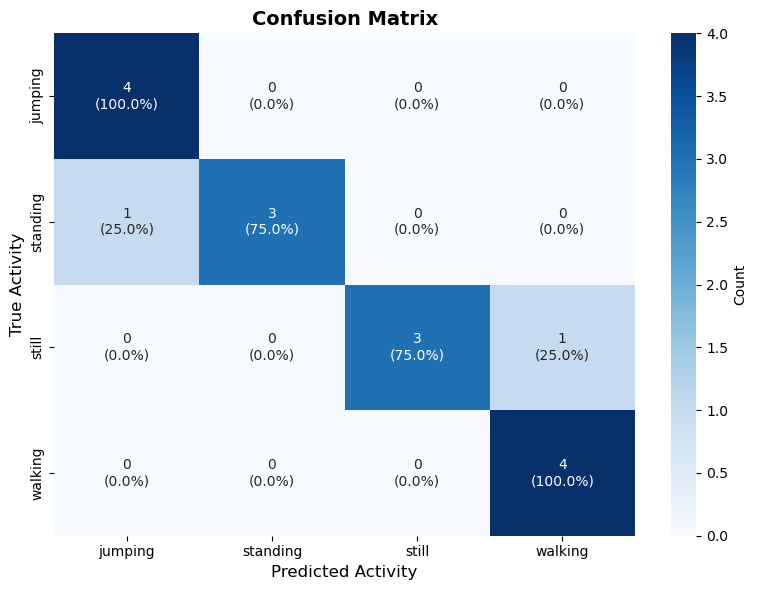


Diagonal values show correct predictions.
Off-diagonal values show misclassifications.


In [8]:
def plot_confusion_matrix(cm, activities):
    """Plot confusion matrix as heatmap."""
    plt.figure(figsize=(8, 6))
    
    # Compute percentages
    cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    
    # Create annotations combining counts and percentages
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)"
    
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
                xticklabels=activities, yticklabels=activities,
                cbar_kws={"label": "Count"})
    
    plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
    plt.xlabel("Predicted Activity", fontsize=12)
    plt.ylabel("True Activity", fontsize=12)
    plt.tight_layout()
    plt.show()

# Plot confusion matrix
plot_confusion_matrix(cm, ACTIVITIES)
print("\nDiagonal values show correct predictions.")
print("Off-diagonal values show misclassifications.")

## 9. Visualize Transition Matrices

Display the transition matrix for each activity's HMM.

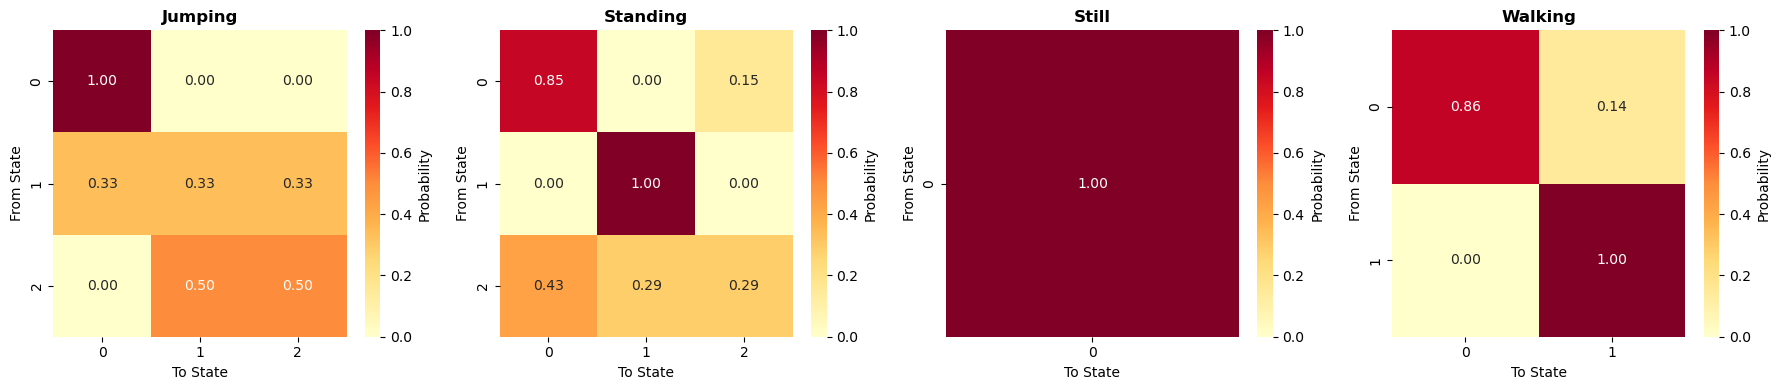


Transition matrices show how each activity's HMM moves between hidden states.
High diagonal values indicate states tend to persist over time.


In [9]:
def plot_transition_matrices(hmm_models, activities):
    """Plot transition matrix for each activity's HMM."""
    n_activities = len(activities)
    fig, axes = plt.subplots(1, n_activities, figsize=(18, 4))
    
    if n_activities == 1:
        axes = [axes]
    
    for idx, activity in enumerate(activities):
        model = hmm_models[activity]
        
        ax = axes[idx]
        sns.heatmap(model.transmat_, annot=True, fmt=".2f", cmap="YlOrRd",
                    cbar_kws={"label": "Probability"},
                    ax=ax, vmin=0, vmax=1)
        
        ax.set_title(f"{activity.capitalize()}", fontsize=12, fontweight="bold")
        ax.set_xlabel("To State")
        ax.set_ylabel("From State")
    
    plt.tight_layout()
    plt.show()

# Plot transition matrices
plot_transition_matrices(hmm_models, ACTIVITIES)
print("\nTransition matrices show how each activity's HMM moves between hidden states.")
print("High diagonal values indicate states tend to persist over time.")

## 10. Analyze Log-Likelihood Scores

Visualize how confidently the model distinguishes between activities.

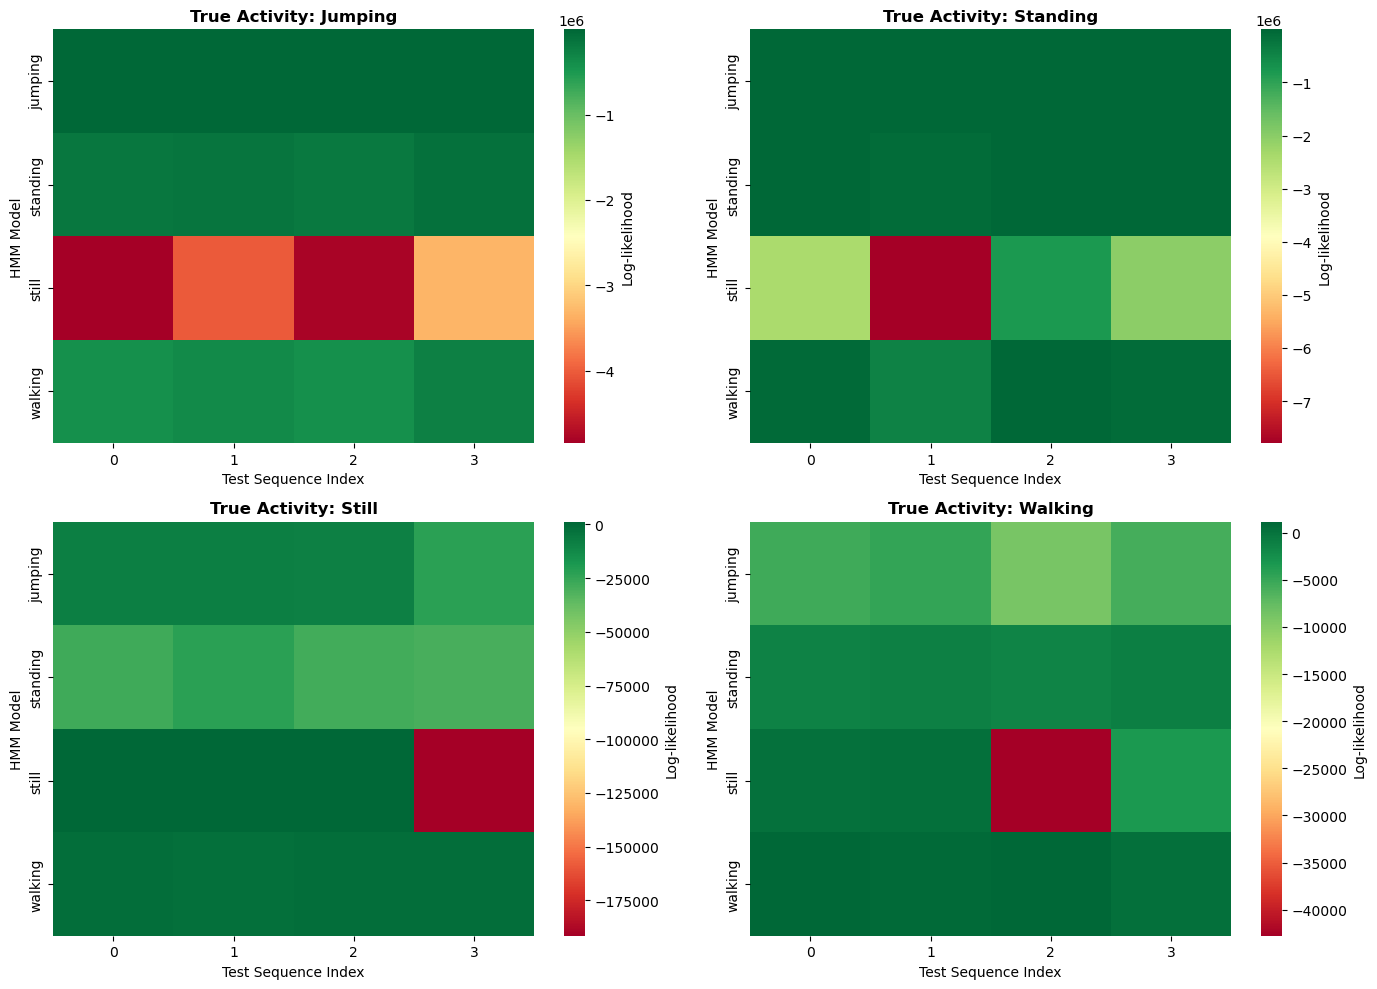


Higher (greener) scores indicate better match.
For correct predictions, the true activity's HMM should have the highest score.


In [10]:
def plot_likelihood_scores(true_labels, all_scores, activities):
    """Plot log-likelihood scores for each test sequence."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, activity in enumerate(activities):
        ax = axes[idx]
        
        # Get scores for sequences of this activity
        activity_indices = [i for i, label in enumerate(true_labels) if label == activity]
        
        if not activity_indices:
            ax.text(0.5, 0.5, f"No test samples for {activity}", 
                   ha='center', va='center', transform=ax.transAxes)
            continue
        
        # Extract scores
        scores_matrix = []
        for i in activity_indices:
            scores_dict = all_scores[i]
            scores_list = [scores_dict[act] for act in activities]
            scores_matrix.append(scores_list)
        
        scores_matrix = np.array(scores_matrix)
        
        # Plot heatmap
        sns.heatmap(scores_matrix.T, annot=False, cmap="RdYlGn", 
                   yticklabels=activities, ax=ax,
                   cbar_kws={"label": "Log-likelihood"})
        
        ax.set_title(f"True Activity: {activity.capitalize()}", fontweight="bold")
        ax.set_xlabel("Test Sequence Index")
        ax.set_ylabel("HMM Model")
    
    plt.tight_layout()
    plt.show()

# Plot likelihood analysis
plot_likelihood_scores(true_labels, all_scores, ACTIVITIES)
print("\nHigher (greener) scores indicate better match.")
print("For correct predictions, the true activity's HMM should have the highest score.")

## 11. Decode State Sequences (Viterbi Algorithm)

Use Viterbi algorithm to decode the most likely hidden state sequence for sample recordings.

  VITERBI DECODING - HIDDEN STATE SEQUENCES

Jumping: jumping_09
  Windows: 6
  State sequence: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


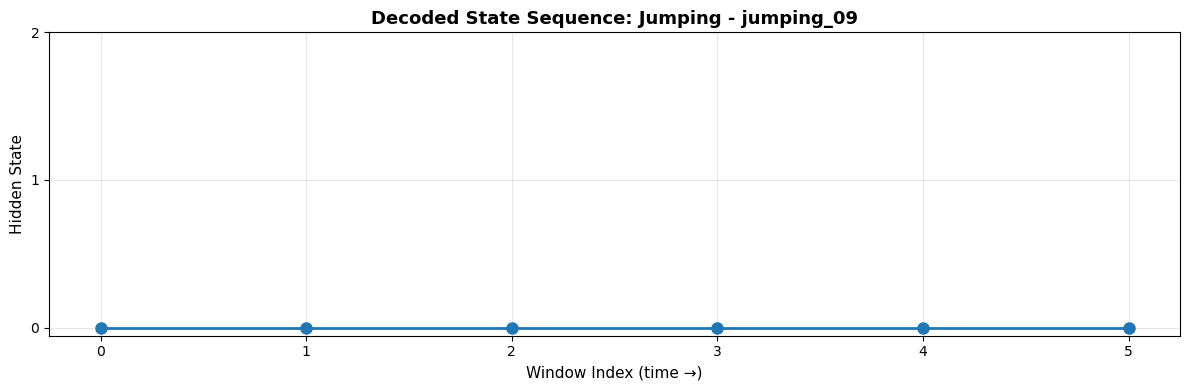


Standing: standing_09
  Windows: 7
  State sequence: [np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]


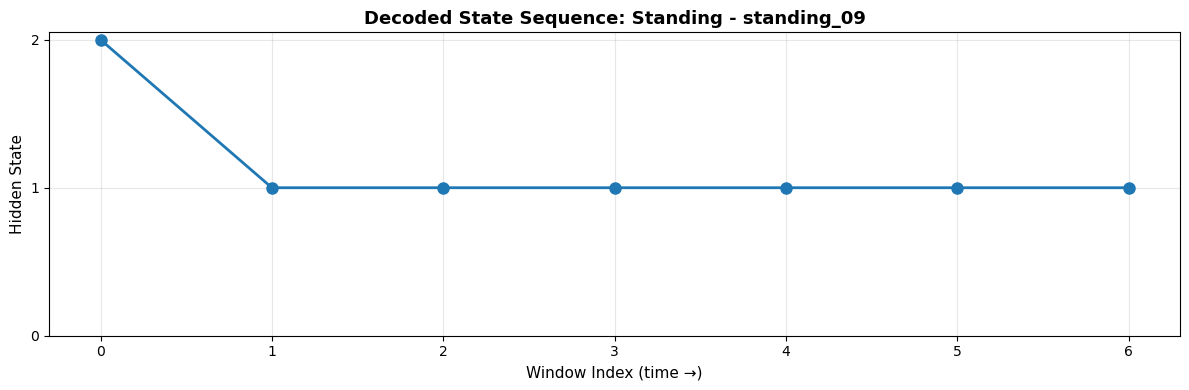


Still: still_09
  Windows: 5
  State sequence: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


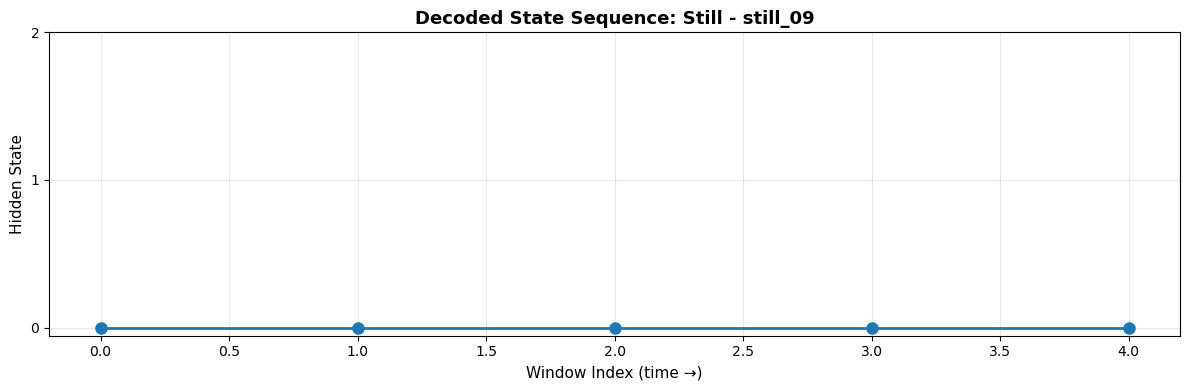


Walking: walking_11
  Windows: 5
  State sequence: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]


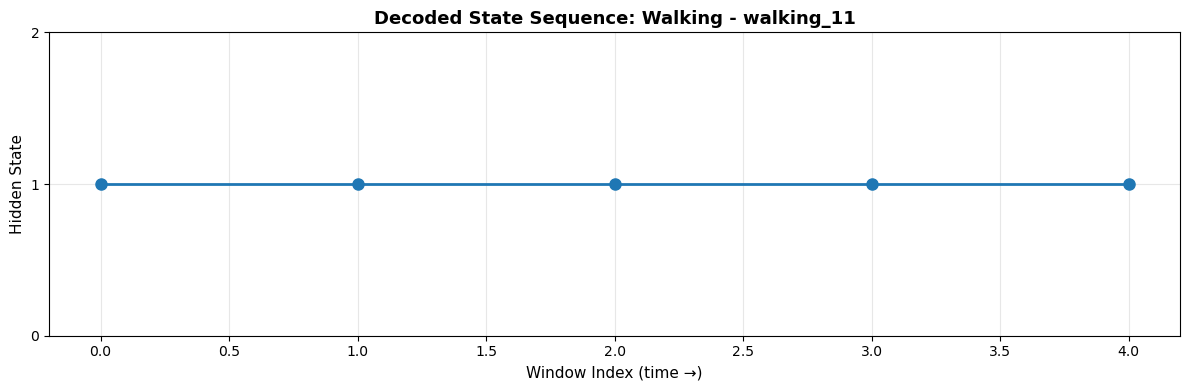


The decoded sequences show how the HMM transitions through hidden states over time.


In [11]:
def decode_sequence_viterbi(sequence, model):
    """Use Viterbi algorithm to find most likely state sequence."""
    features = sequence["features"]
    states = model.predict(features)
    return states


def plot_state_sequence(sequence, states, activity):
    """Plot the decoded state sequence for one recording."""
    n_windows = len(states)
    
    plt.figure(figsize=(12, 4))
    plt.plot(range(n_windows), states, marker='o', linewidth=2, markersize=8)
    plt.title(f"Decoded State Sequence: {activity.capitalize()} - {sequence['sequence_id']}", 
             fontsize=13, fontweight="bold")
    plt.xlabel("Window Index (time →)", fontsize=11)
    plt.ylabel("Hidden State", fontsize=11)
    plt.yticks(range(N_HIDDEN_STATES))
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Decode and plot for first test sequence of each activity
print("="*70)
print("  VITERBI DECODING - HIDDEN STATE SEQUENCES")
print("="*70)

for activity in ACTIVITIES:
    # Find first test sequence of this activity
    seq = next((s for s in test_sequences_norm if s["activity"] == activity), None)
    
    if seq is None:
        print(f"\n⚠ No test sequence for {activity}")
        continue
    
    # Decode using Viterbi
    model = hmm_models[activity]
    states = decode_sequence_viterbi(seq, model)
    
    print(f"\n{activity.capitalize()}: {seq['sequence_id']}")
    print(f"  Windows: {len(states)}")
    print(f"  State sequence: {list(states)}")
    
    # Plot
    plot_state_sequence(seq, states, activity)

print("\nThe decoded sequences show how the HMM transitions through hidden states over time.")

## 12. Save Results and Models

In [12]:
def save_results(hmm_models, metrics, overall_acc, cm, output_dir):
    """Save all models and evaluation results."""
    os.makedirs(output_dir, exist_ok=True)
    
    # Save each HMM model
    for activity, model in hmm_models.items():
        model_path = os.path.join(output_dir, f"hmm_{activity}.pkl")
        with open(model_path, "wb") as f:
            pickle.dump(model, f)
        print(f"✓ Saved: hmm_{activity}.pkl")
    
    # Save normalization parameters
    norm_path = os.path.join(output_dir, "normalization.pkl")
    with open(norm_path, "wb") as f:
        pickle.dump({"mean": mean, "std": std}, f)
    print(f"✓ Saved: normalization.pkl")
    
    # Save evaluation report (JSON)
    report = {
        "overall_accuracy": float(overall_acc),
        "n_hidden_states": N_HIDDEN_STATES,
        "n_features": int(n_features),
        "train_sequences": len(train_sequences),
        "test_sequences": len(test_sequences),
        "activities": ACTIVITIES,
        "per_activity_metrics": [
            {
                "activity": ACTIVITIES[i],
                "n_test_samples": int(cm[i, :].sum()),
                "sensitivity": float(metrics[i]["sensitivity"]),
                "specificity": float(metrics[i]["specificity"]),
                "accuracy": float(metrics[i]["accuracy"]),
                "tp": int(metrics[i]["tp"]),
                "fp": int(metrics[i]["fp"]),
                "fn": int(metrics[i]["fn"]),
                "tn": int(metrics[i]["tn"])
            }
            for i in range(len(ACTIVITIES))
        ],
        "transition_matrices": {
            activity: model.transmat_.tolist()
            for activity, model in hmm_models.items()
        },
        "confusion_matrix": cm.tolist()
    }
    
    report_path = os.path.join(output_dir, "evaluation_report.json")
    with open(report_path, "w") as f:
        json.dump(report, f, indent=2)
    print(f"✓ Saved: evaluation_report.json")
    
    # Save text report
    txt_path = os.path.join(output_dir, "evaluation_report.txt")
    with open(txt_path, "w") as f:
        f.write("="*70 + "\n")
        f.write("SEQUENCE-BASED HMM ACTIVITY RECOGNITION - EVALUATION REPORT\n")
        f.write("="*70 + "\n\n")
        f.write(f"Overall Accuracy: {overall_acc:.2%}\n\n")
        f.write(f"Training sequences: {len(train_sequences)}\n")
        f.write(f"Test sequences: {len(test_sequences)}\n")
        f.write(f"Hidden states per HMM: {N_HIDDEN_STATES}\n")
        f.write(f"Feature dimensions: {n_features}\n\n")
        f.write("-"*70 + "\n")
        f.write(f"{'State (Activity)':<20} {'Samples':>10} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10}\n")
        f.write("-"*70 + "\n")
        for item in report["per_activity_metrics"]:
            f.write(f"{item['activity']:<20} {item['n_test_samples']:>10} "
                   f"{item['sensitivity']:>11.1%} {item['specificity']:>11.1%} "
                   f"{item['accuracy']:>9.1%}\n")
        f.write("-"*70 + "\n\n")
        f.write("Confusion Matrix:\n")
        f.write(str(cm) + "\n")
    print(f"✓ Saved: evaluation_report.txt")


# Save all results
print("\n" + "="*70)
print("  SAVING RESULTS")
print("="*70 + "\n")

save_results(hmm_models, metrics, overall_acc, cm, OUTPUT_DIR)

print("\n" + "="*70)
print("  ALL RESULTS SAVED SUCCESSFULLY")
print("="*70)
print(f"\nOutput directory: {OUTPUT_DIR}/")
print("  Files created:")
print("    - hmm_<activity>.pkl (4 trained HMM models)")
print("    - normalization.pkl (feature normalization parameters)")
print("    - evaluation_report.json (metrics in JSON format)")
print("    - evaluation_report.txt (human-readable report)")


  SAVING RESULTS

✓ Saved: hmm_jumping.pkl
✓ Saved: hmm_standing.pkl
✓ Saved: hmm_still.pkl
✓ Saved: hmm_walking.pkl
✓ Saved: normalization.pkl
✓ Saved: evaluation_report.json
✓ Saved: evaluation_report.txt

  ALL RESULTS SAVED SUCCESSFULLY

Output directory: hmm_sequence_results/
  Files created:
    - hmm_<activity>.pkl (4 trained HMM models)
    - normalization.pkl (feature normalization parameters)
    - evaluation_report.json (metrics in JSON format)
    - evaluation_report.txt (human-readable report)


## Summary

This notebook implemented a **proper sequence-based HMM** for activity recognition:

### Key Points:

1. **Data Structure**: Each recording is a sequence of feature observations (not a single vector)

2. **Model Architecture**: One HMM trained per activity class (4 HMMs total)

3. **Algorithms**:
   - **Baum-Welch**: Trained transition and emission probabilities
   - **Viterbi**: Decoded most likely hidden state sequences

4. **Classification**: Log-likelihood scoring - sequence assigned to HMM with highest score

5. **Features**: Time-domain (mean, std, var, SMA, correlations) + Frequency-domain (FFT, spectral energy)

### For Your Report:

- **Hidden States**: Internal phases within each activity (e.g., heel strike, mid-stance, push-off for walking)
- **Observations**: 74-dimensional feature vectors from 2-second windows
- **Transition Matrix**: Shows temporal dynamics within activities
- **Evaluation**: Sensitivity, specificity, and accuracy per activity on unseen test data